# AG-HYPOPT · Trial 10

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Nine trials. Leader: **trial_06** `cvm_fwhm` **0.0764** (sw 0.2074), with the same family at sw 0.2345 ->
0.0777 and sw 0.1816 -> 0.0791; the KDE control is **0.080328**. Trial_07 (KDE at sw 0.2279 -> 0.0830)
and trial_09 (`energy_2d` at sw 0.2291 -> 0.1021, no better than its high-sw 0.0996) together show the
low-sw gain is **specific to `cvm_fwhm`**, i.e. a real loss-form effect. Outstanding checks: the other
families have not yet been run at the winning sw - `w1_2d` (0.0895 at sw 0.41) is the most promising
untested-at-low-sw family, since `mmd_2d` and `energy_2d` are already clearly weak. No divergences.
Phase `trials` (9/5), EI-guided.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_10'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (9/5 trials)
ID |     ei | params
 1 | 2.7051 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.8284448852745308}
 2 | 2.4059 | {"loss_family": "w1_2d", "sigma_weight": 0.20915674145175503}
 3 | 3.1465 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.240921426059944}
 4 | 3.2944 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.2235166496675614}
 5 | 2.4351 | {"loss_family": "w1_fwhm", "sigma_weight": 0.22139218967620267}
 6 | 2.4771 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.7455802110439375}
 7 | 2.4351 | {"loss_family": "w1_2d", "sigma_weight": 0.22121568700429983}
 8 | 2.7364 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.9698303682063217}
 9 |      - | {"loss_family": "w1_2d", "sigma_weight": 0.32247455876606135}
10 |      - | {"loss_family": "mmd_2d", "sigma_weight": 0.28243351716467957}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

EI again puts `cvm_fwhm` near sw 0.22-0.24 on top (candidates 3, 4), but those merely repeat the sw band
already bracketed by trials 05/06/08 - low information. The one remaining structural gap is whether the
**second-best family, `w1_2d`, also improves at the winning sw**: it has only ever been run at sw 0.409
(0.0895), and `cvm_fwhm` gained ~0.013 by moving from 0.41-ish to 0.21. If `w1_2d` does the same, the
family ranking could change.

Scanning the table: candidates 2 and 7 are exactly this test - `w1_2d` at sw 0.2092 (ei 2.4059) and
0.2212 (ei 2.4351). Candidate 5 is `w1_fwhm` at sw 0.2214 (the FWHM-only W1 variant, also untested at
low sw) but `w1_2d` is the more direct comparison and is the better family of the two. Candidate 2 sits
closest to trial_06's sw (0.2074), so it is the cleanest A/B against the current best.

I choose candidate 2.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 2             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'w1_2d', 'sigma_weight': 0.20915674145175503}
Running  1nW Trans05 ... 

μ 9.39 -> 5.97 | γ 8.5 -> 3.29 | NLL 19.93


Running  1nW Trans20 ... 

μ 17.32 -> 27.87 | γ 8.5 -> 5.81 | NLL 3.92


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 65.08 | γ 14.1 -> 12.94 | NLL 1.92


Running 3nW Trans100 ... 

μ 175.71 -> 98.24 | γ 14.1 -> 13.62 | NLL 1.54



Total: 7.8 min


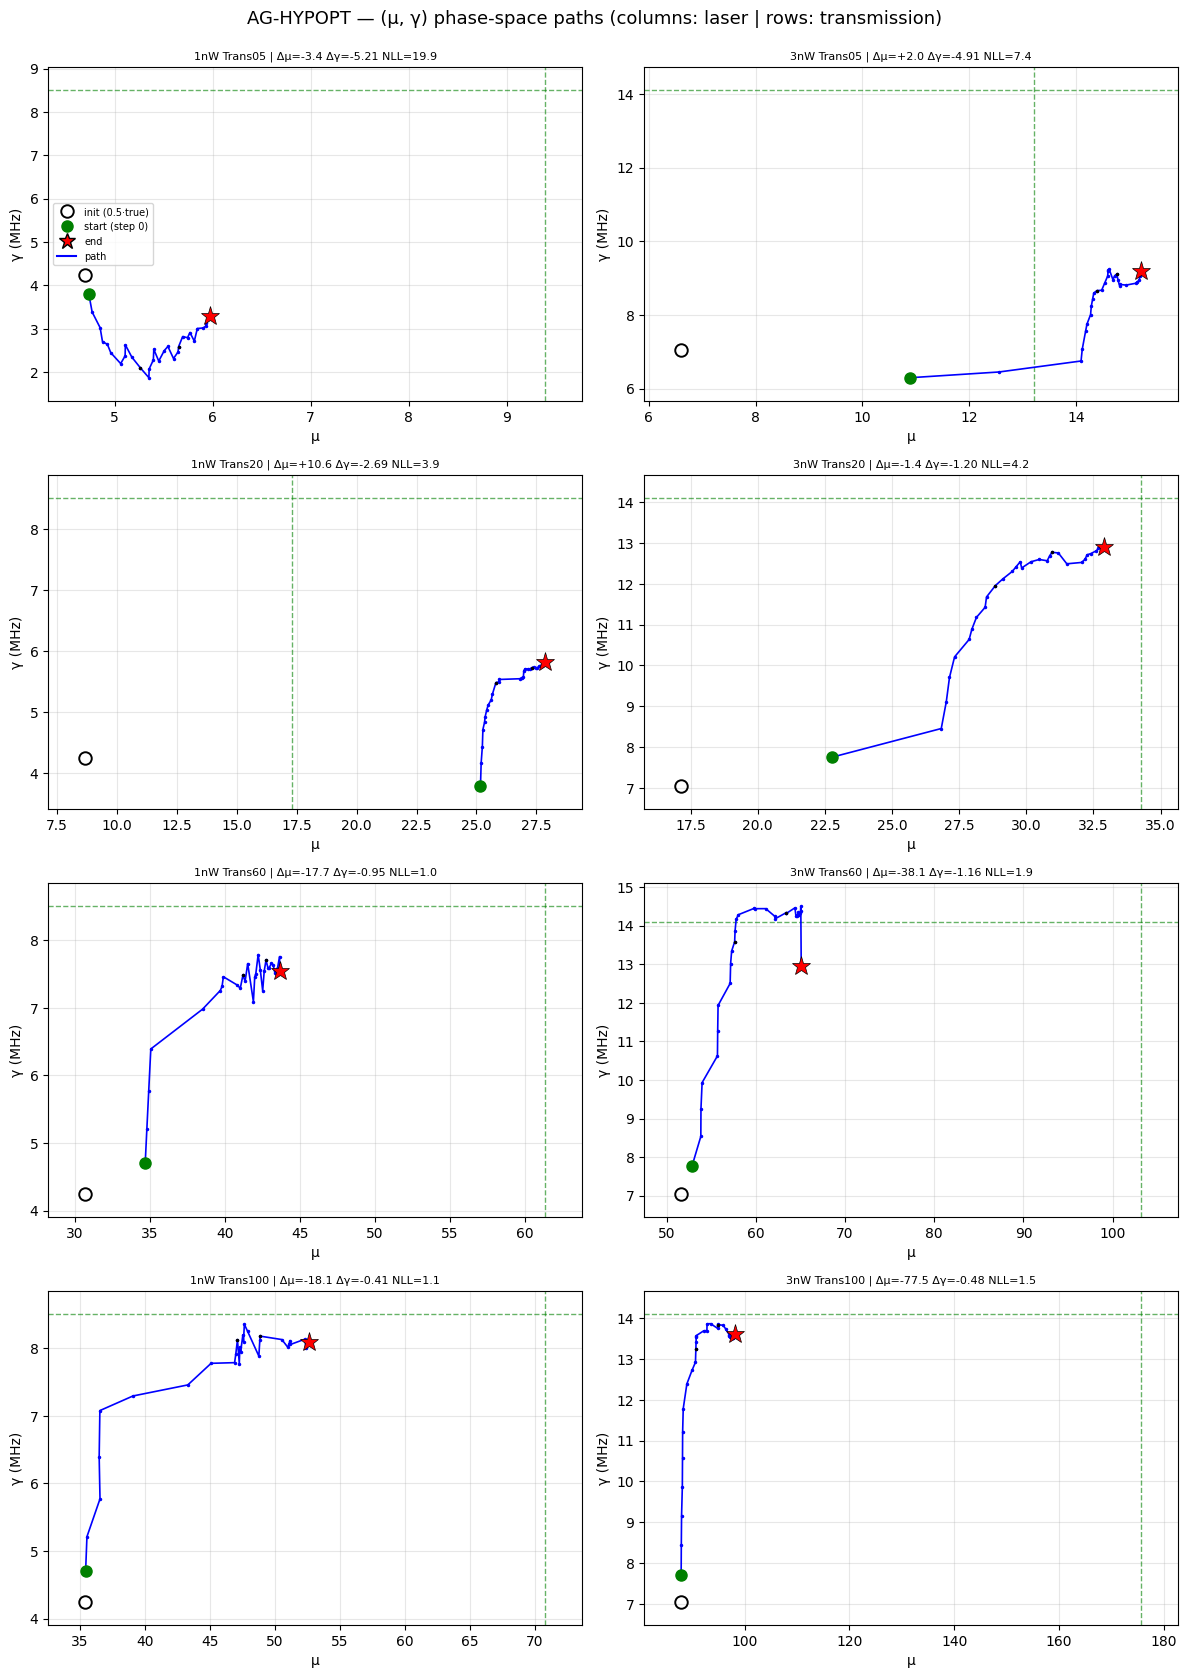

trial finished in 7.8 min
objective = 0.0849 ± 0.0305
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.97   -36.5 |     8.50    3.29   -61.3
1nW Trans20       17.32   27.87   +61.0 |     8.50    5.81   -31.6
1nW Trans60       61.37   43.68   -28.8 |     8.50    7.55   -11.2
1nW Trans100       70.82   52.67   -25.6 |     8.50    8.09    -4.9
3nW Trans05       13.20   15.22   +15.3 |    14.10    9.19   -34.8
3nW Trans20       34.28   32.88    -4.1 |    14.10   12.90    -8.5
3nW Trans60      103.20   65.08   -36.9 |    14.10   12.94    -8.2
3nW Trans100      175.71   98.24   -44.1 |    14.10   13.62    -3.4

weighted objective (T-graded, cap=1.0) = 0.0849 | diverged cells: 0
μ: RMSE 32.067 (rel 35.5%, bias -17.962) | γ: RMSE 2.797 (rel 28.0%, bias -2.127)


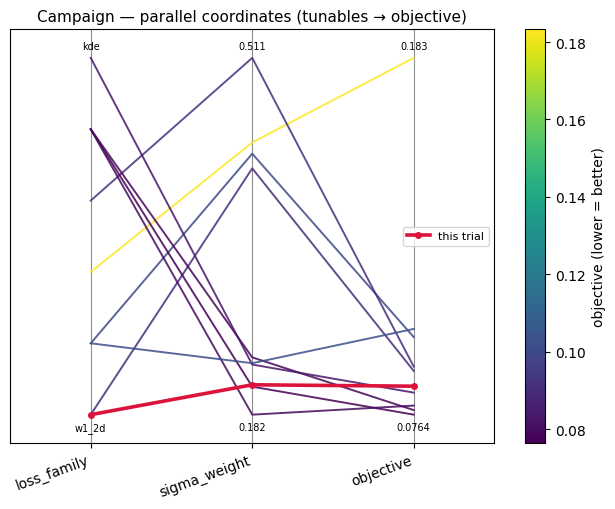

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'w1_2d', sigma_weight: 0.2092}` (candidate 2). Trial time
7.8 min, objective **0.0849 +/- 0.0305**, **0 diverged cells**. `w1_2d` *does* improve at the winning sw:
0.0849 here vs 0.0895 at sw 0.4092 in trial_01 (a gain of ~0.0046), but the gain is smaller than
`cvm_fwhm`'s, so `w1_2d` still trails both the KDE control (0.0803) and `cvm_fwhm` (0.0764).

**Per-cell behaviour.**

- 1nW Trans05: mu -36.5 %, gamma 8.5 -> 3.29 (-61.3 %) - still a low-count gamma collapse, much worse
  than `cvm_fwhm`'s -50 %.
- 1nW Trans20: mu +61.0 %, gamma -31.6 %.
- 1nW Trans60 / Trans100: mu -28.8 % / -25.6 %, gamma -11.2 % / -4.9 % - the high-T cells are among
  the best of the campaign.
- 3nW Trans05 / Trans20: mu +15.3 % / -4.1 %, gamma -34.8 % / -8.5 %.
- 3nW Trans60 / Trans100: mu -36.9 % / -44.1 %, gamma -8.2 % / -3.4 %.

**Aggregates.** mu: RMSE 32.07 (rel 35.5 %), bias -17.96; gamma: RMSE 2.80 (rel 28.0 %), bias -2.13 -
better than `w1_2d`'s high-sw trial on both channels, but still behind `cvm_fwhm`. The weakness is
concentrated at low count (1nW Trans05 gamma -61 %).

**Summary:** `w1_2d` at sw 0.2092 gives objective 0.0849 - an improvement on its high-sw value (0.0895)
but still behind the KDE control (0.0803) and well behind `cvm_fwhm` (0.0764), with a low-count gamma
collapse.
**Key insight:** The low-sw benefit is not exclusive to `cvm_fwhm` (`w1_2d` gains ~0.005 too), but
`cvm_fwhm` gains roughly three times as much (0.013), so its lead reflects the loss form, not just sw.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'w1_2d at sigma_weight 0.2092 gives objective 0.0849, an improvement on its high-sw value (0.0895) but still behind the KDE control (0.0803) and well behind cvm_fwhm (0.0764).'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'The low-sw benefit is not exclusive to cvm_fwhm (w1_2d gains ~0.005 too), but cvm_fwhm gains roughly three times as much (0.013), so its lead reflects the loss form rather than sw alone.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_10 | current best: trial_06


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_11.ipynb. Open it and follow its cells from the top.
